In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("loan_prediction_dataset.csv")
prepared = data.copy()

fill_by_mode = ["Gender", "Married", "Dependents", "Self_Employed", "Credit_History"]
fill_by_median = ["LoanAmount", "Loan_Amount_Term"]

for column in fill_by_mode:
    prepared[column] = prepared[column].fillna(prepared[column].mode().iloc[0])

for column in fill_by_median:
    prepared[column] = prepared[column].fillna(prepared[column].median())

prepared.isna().sum()


,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


# Задание 1


## Подготовим две небольшие функции для поиска крайних значений


In [2]:
def iqr_limits(values):
    first_quartile, third_quartile = values.quantile([0.25, 0.75])
    spread = third_quartile - first_quartile
    left_edge = first_quartile - 1.5 * spread
    right_edge = third_quartile + 1.5 * spread
    mask = (values < left_edge) | (values > right_edge)
    return {
        "outliers": values[mask],
        "low": left_edge,
        "high": right_edge
    }


def sigma_limits(values, k=3):
    center = values.mean()
    deviation = values.std()
    left_edge = center - k * deviation
    right_edge = center + k * deviation
    mask = (values < left_edge) | (values > right_edge)
    return {
        "outliers": values[mask],
        "low": left_edge,
        "high": right_edge
    }


## Проверим `ApplicantIncome` и `LoanAmount` по IQR-правилу


In [3]:
applicant_iqr = iqr_limits(prepared["ApplicantIncome"])
loan_iqr = iqr_limits(prepared["LoanAmount"])

print(f"ApplicantIncome: границы [{applicant_iqr['low']:.2f}; {applicant_iqr['high']:.2f}], выбросов = {applicant_iqr['outliers'].shape[0]}")
print(f"LoanAmount: границы [{loan_iqr['low']:.2f}; {loan_iqr['high']:.2f}], выбросов = {loan_iqr['outliers'].shape[0]}")

applicant_iqr["outliers"].head(), loan_iqr["outliers"].head()


ApplicantIncome: границы [-1498.75; 10171.25], выбросов = 50
LoanAmount: границы [3.50; 261.50], выбросов = 41


(9      12841
 34     12500
 54     11500
 67     10750
 102    13650
 Name: ApplicantIncome, dtype: int64,
 5     267.0
 9     349.0
 21    315.0
 34    320.0
 54    286.0
 Name: LoanAmount, dtype: float64)

## Теперь применим правило трёх стандартных отклонений


In [4]:
applicant_sigma = sigma_limits(prepared["ApplicantIncome"])
loan_sigma = sigma_limits(prepared["LoanAmount"])

print(f"ApplicantIncome: границы [{applicant_sigma['low']:.2f}; {applicant_sigma['high']:.2f}], выбросов = {applicant_sigma['outliers'].shape[0]}")
print(f"LoanAmount: границы [{loan_sigma['low']:.2f}; {loan_sigma['high']:.2f}], выбросов = {loan_sigma['outliers'].shape[0]}")

applicant_sigma["outliers"].head(), loan_sigma["outliers"].head()


ApplicantIncome: границы [-12923.67; 23730.58], выбросов = 8
LoanAmount: границы [-106.57; 398.07], выбросов = 15


(126    23803
 155    39999
 171    51763
 183    33846
 185    39147
 Name: ApplicantIncome, dtype: int64,
 130    650.0
 155    600.0
 171    700.0
 177    495.0
 278    436.0
 Name: LoanAmount, dtype: float64)

# Задание 2


In [5]:
comparison = {
    "ApplicantIncome": {
        "iqr": set(applicant_iqr["outliers"].index),
        "std": set(applicant_sigma["outliers"].index)
    },
    "LoanAmount": {
        "iqr": set(loan_iqr["outliers"].index),
        "std": set(loan_sigma["outliers"].index)
    }
}

for feature, groups in comparison.items():
    common = groups["iqr"] & groups["std"]
    iqr_unique = groups["iqr"] - groups["std"]
    std_unique = groups["std"] - groups["iqr"]

    print(feature)
    print("Совпали у двух методов:", len(common))
    print("Есть только у IQR:", len(iqr_unique))
    print("Есть только у std:", len(std_unique))
    print("-" * 40)


ApplicantIncome
Совпали у двух методов: 8
Есть только у IQR: 42
Есть только у std: 0
----------------------------------------
LoanAmount
Совпали у двух методов: 15
Есть только у IQR: 26
Есть только у std: 0
----------------------------------------


**Комментарий.**  
Разница между результатами возникает из-за того, что методы опираются на разные характеристики распределения.

- IQR использует квартили и межквартильный размах, поэтому он устойчивее к сильной асимметрии.
- Метод через стандартное отклонение опирается на среднее и разброс вокруг него, поэтому сильные экстремумы сами влияют на расчёт границ.

Из-за этого на скошенных распределениях набор найденных наблюдений может отличаться.


# Задание 3


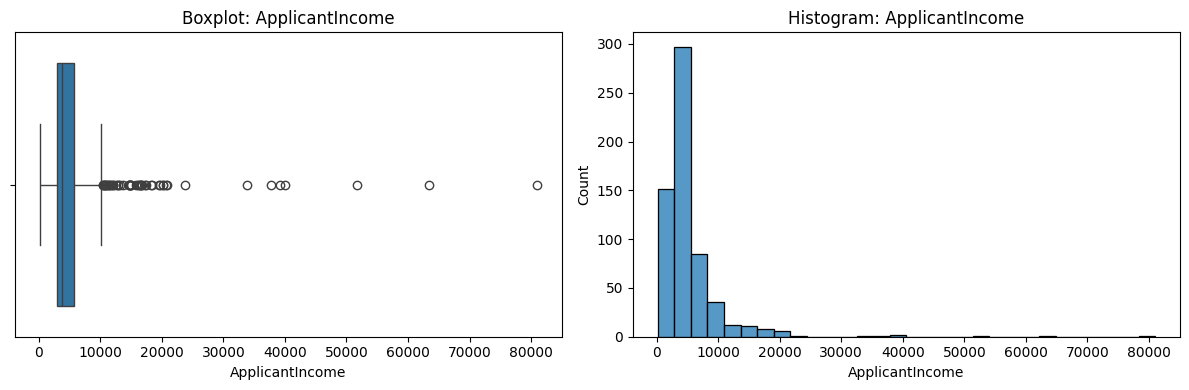

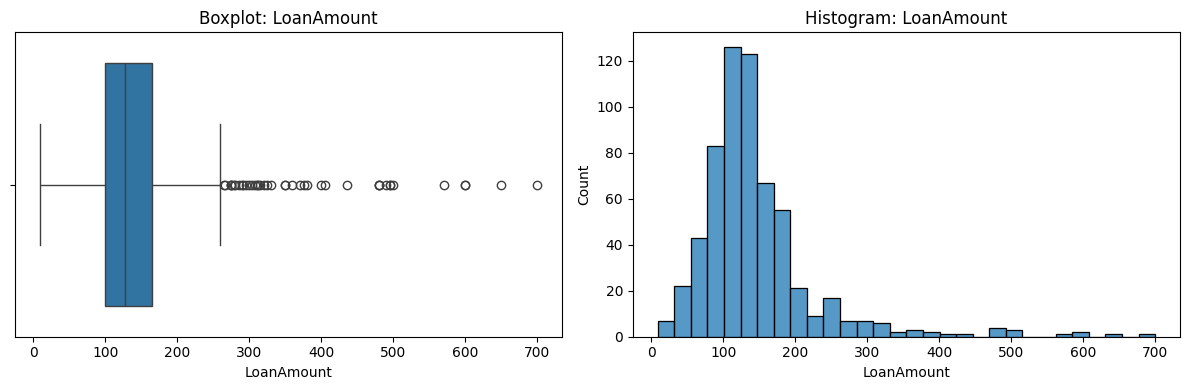

In [6]:
features = ["ApplicantIncome", "LoanAmount"]

for feature in features:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.boxplot(x=prepared[feature], ax=axes[0])
    axes[0].set_title(f"Boxplot: {feature}")
    axes[0].set_xlabel(feature)

    sns.histplot(prepared[feature], bins=30, ax=axes[1])
    axes[1].set_title(f"Histogram: {feature}")
    axes[1].set_xlabel(feature)
    axes[1].set_ylabel("Count")

    plt.tight_layout()
    plt.show()


По графикам видно, что у обоих признаков есть значения, заметно удалённые от основной массы наблюдений.  
Особенно хорошо это видно на boxplot, а гистограммы дополнительно показывают правостороннюю асимметрию распределений.


# Задание 4


В этом наборе данных выбросы лучше не удалять, а ограничить сверху и снизу по границам IQR.

**Пояснение:**
- удаление строк уменьшит объём данных;
- большие доходы и суммы кредита могут быть реальными значениями;
- ограничение уменьшает влияние крайних наблюдений, но сохраняет все записи.


In [7]:
capped = prepared.copy()

borders = {
    "ApplicantIncome": (applicant_iqr["low"], applicant_iqr["high"]),
    "LoanAmount": (loan_iqr["low"], loan_iqr["high"])
}

for feature, (low, high) in borders.items():
    capped[feature] = capped[feature].where(capped[feature] >= low, low)
    capped[feature] = capped[feature].where(capped[feature] <= high, high)

capped[["ApplicantIncome", "LoanAmount"]].describe()


,ApplicantIncome,LoanAmount
count,614.000000,614.000000
mean,4617.111564,137.365635
std,2479.851729,55.779749
min,150.000000,9.000000
25%,2877.500000,100.250000
50%,3812.500000,128.000000
75%,5795.000000,164.750000
max,10171.250000,261.500000


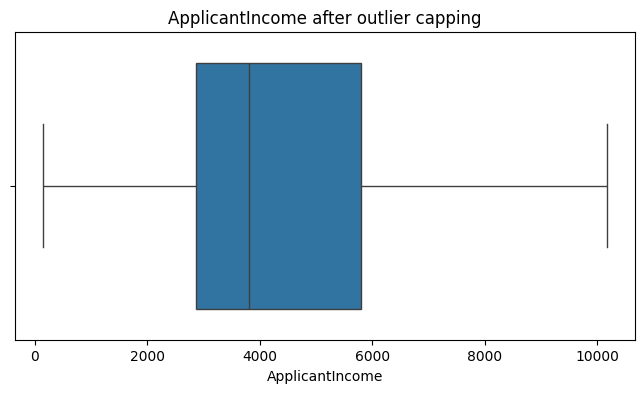

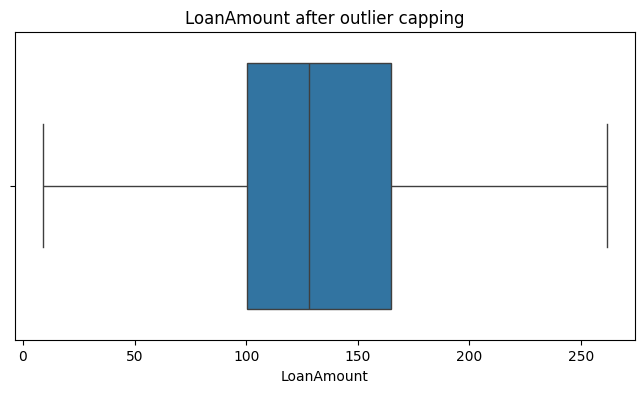

In [8]:
for feature in ["ApplicantIncome", "LoanAmount"]:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=capped[feature])
    plt.title(f"{feature} after outlier capping")
    plt.xlabel(feature)
    plt.show()


После такой обработки экстремальные значения уже не так сильно выделяются, но сам датасет при этом не сократился.


# Задание 5

Для категориальных признаков можно выбрать разные способы кодирования в зависимости от их смысла.

- `Gender`, `Married`, `Education`, `Self_Employed`, `Loan_Status` — бинарные признаки, поэтому удобно закодировать их числами `0` и `1`.
- `Dependents` можно перевести в обычное числовое значение, потому что здесь есть естественный порядок по количеству иждивенцев.
- `Property_Area` лучше преобразовать через One-Hot Encoding, так как его категории не образуют естественную шкалу и не должны искусственно упорядочиваться.


# Задание 6


In [9]:
encoded = capped.copy()

binary_maps = {
    "Gender": {"Female": 0, "Male": 1},
    "Married": {"No": 0, "Yes": 1},
    "Education": {"Not Graduate": 0, "Graduate": 1},
    "Self_Employed": {"No": 0, "Yes": 1},
    "Loan_Status": {"N": 0, "Y": 1}
}

for column, mapping in binary_maps.items():
    encoded[column] = encoded[column].replace(mapping)

encoded["Dependents"] = encoded["Dependents"].replace({"3+": 3}).astype(int)

area_dummies = pd.get_dummies(encoded["Property_Area"], prefix="Property_Area", dtype=int)
encoded = pd.concat([encoded.drop(columns=["Property_Area"]), area_dummies], axis=1)

encoded.head()


/tmp/ipykernel_160/3412369872.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  encoded[column] = encoded[column].replace(mapping)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,LP001002,1,0,0,1,0,5849.0,0.0,128.0,360.0,1.0,1,0,0,1
1,LP001003,1,1,1,1,0,4583.0,1508.0,128.0,360.0,1.0,0,1,0,0
2,LP001005,1,1,0,1,1,3000.0,0.0,66.0,360.0,1.0,1,0,0,1
3,LP001006,1,1,0,0,0,2583.0,2358.0,120.0,360.0,1.0,1,0,0,1
4,LP001008,1,0,0,1,0,6000.0,0.0,141.0,360.0,1.0,1,0,0,1


# Задание 7


In [10]:
encoded.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Loan_ID                  614 non-null    object 
 1   Gender                   614 non-null    int64  
 2   Married                  614 non-null    int64  
 3   Dependents               614 non-null    int64  
 4   Education                614 non-null    int64  
 5   Self_Employed            614 non-null    int64  
 6   ApplicantIncome          614 non-null    float64
 7   CoapplicantIncome        614 non-null    float64
 8   LoanAmount               614 non-null    float64
 9   Loan_Amount_Term         614 non-null    float64
 10  Credit_History           614 non-null    float64
 11  Loan_Status              614 non-null    int64  
 12  Property_Area_Rural      614 non-null    int64  
 13  Property_Area_Semiurban  614 non-null    int64  
 14  Property_Area_Urban      6

In [11]:
print("Итоговая размерность:", encoded.shape)
print("Всего пропусков после преобразований:", encoded.isna().sum().sum())


Итоговая размерность: (614, 15)
Всего пропусков после преобразований: 0
